In [1]:
from utils import *
from utils.new_custom_classes import ParameterField
from utils.sigmav_functions import *
import numpy as np
import matplotlib.pyplot as plt
import itertools
import plotly.graph_objects as go
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# Parametrization points

In [2]:
# generic number of values for each parameter used for the parametric analysis
param_points = 2
# Number of points for the spatial distribution of parameters
space_points = 1

# Parameters

### Plasma parameters

In [3]:
# Basic parameter fields (no time or spatial dependence)
V_plasma_field = ParameterField(
    parametrization_type="normal", mean=150, std=15, unit=u.m**3, 
    param_points=1, name="plasma_volume"
)

tau_p_T_field = ParameterField(
    parametrization_type="linear", min_val = 1, max_val=10, unit=u.s,
    param_points=1, name="tau_p_T"
)

tau_p_He3_field = ParameterField(
    parametrization_type="normal", mean=1, std=0.5, unit=u.s,
    param_points=1, name="tau_p_He3"
)


############################################################################## IN PRINCIPLE COULD BE t-dependent
P_aux_field = ParameterField(
    parametrization_type="linear", min_val=20, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=20, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

P_aux_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=20, max_val=100, unit=u.MW,
    param_points=1, name="P_aux"
)

P_lost_rad_all_DT_field = ParameterField(
    parametrization_type="linear", min_val=0, max_val=20, unit=u.MW,
    param_points=1, name="P_lost_rad"
)

print("Basic parameter fields created:")
print(f"V_plasma: {V_plasma_field}")
print(f"tau_p_T: {tau_p_T_field}")
print(f"tau_p_He3: {tau_p_He3_field}")
print(f"P_aux: {P_aux_field}")
print(f"P_aux_all_DT: {P_aux_all_DT_field}")
print(f"P_lost_rad: {P_lost_rad_field}")
print(f"P_lost_rad_all_DT: {P_lost_rad_all_DT_field}")

Basic parameter fields created:
V_plasma: <ParameterField 'plasma_volume' type=normal, profile=none, shape=(1,), unit=meter ** 3>
[150.000] meter ** 3
tau_p_T: <ParameterField 'tau_p_T' type=linear, profile=none, shape=(1,), unit=second>
[5.500] second
tau_p_He3: <ParameterField 'tau_p_He3' type=normal, profile=none, shape=(1,), unit=second>
[1.000] second
P_aux: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[60.000] megawatt
P_aux_all_DT: <ParameterField 'P_aux' type=linear, profile=none, shape=(1,), unit=megawatt>
[60.000] megawatt
P_lost_rad: <ParameterField 'P_lost_rad' type=linear, profile=none, shape=(1,), unit=megawatt>
[10.000] megawatt
P_lost_rad_all_DT: <ParameterField 'P_lost_rad' type=linear, profile=none, shape=(1,), unit=megawatt>
[10.000] megawatt


##### Spataial parameters (pedestal profile)

Spatial parameter fields:
T_i_spatial: <ParameterField 'T_i_spatial' type=normal, profile=pedestal, shape=(1,), unit=kiloelectron_volt>
[14.000] kiloelectron_volt
n_tot_spatial: <ParameterField 'n_tot_spatial' type=normal, profile=pedestal, shape=(1,), unit=1 / meter ** 3>
[170000000000000000000.000] 1 / meter ** 3


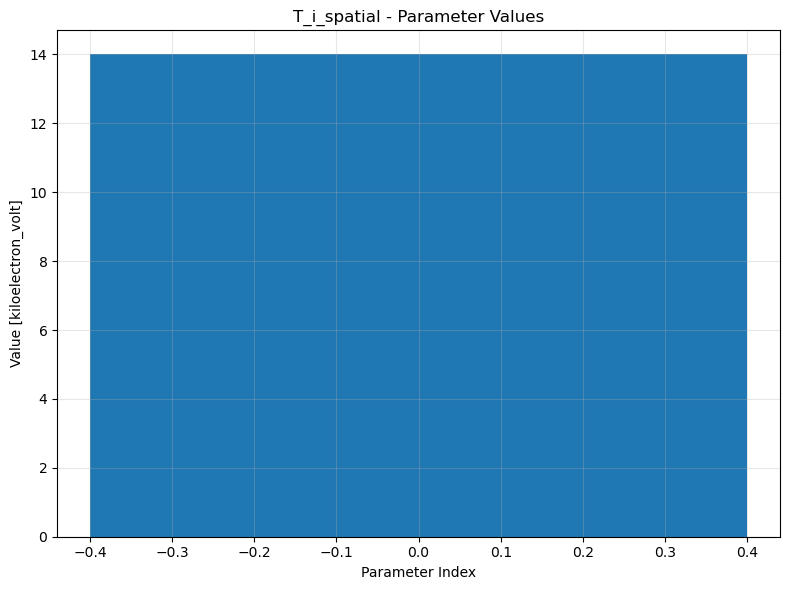

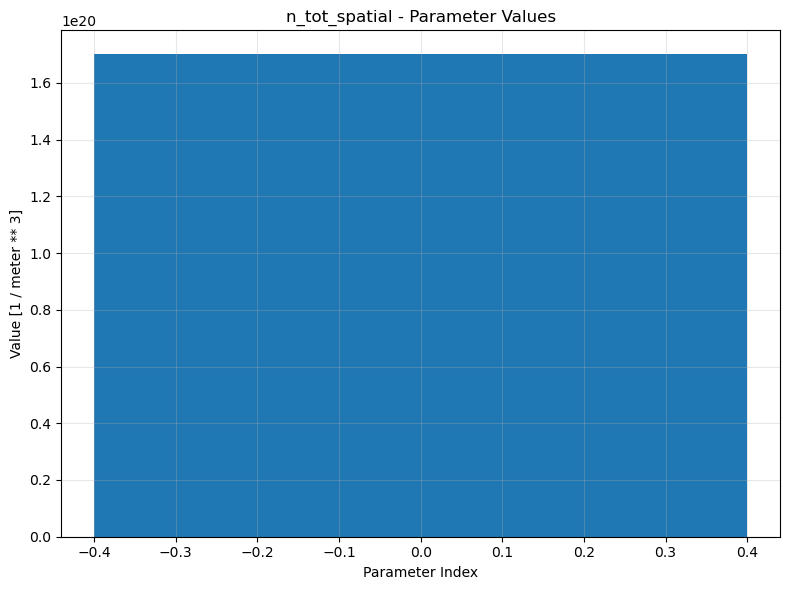

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'n_tot_spatial - Parameter Values'}, xlabel='Parameter Index', ylabel='Value [1 / meter ** 3]'>)

In [4]:
# Create spatial parameter fields for temperature and density
T_i_spatial = ParameterField(
    parametrization_type="normal",
    spatial_profile="pedestal",
    mean=14, std=1, unit=u.keV,
    param_points=1,
    space_points=space_points,
    value_center=1.0,        # Relative to mean
    value_ped=0.22,          # 5.5 keV / 25 keV ≈ 0.22
    value_edge=0.0004,       # 0.01 keV / 25 keV ≈ 0.0004
    transition_ratio=0.95,
    name="T_i_spatial"
)

n_tot_spatial = ParameterField(
    parametrization_type="normal",
    spatial_profile="pedestal", 
    mean=1.7e20, std=1e19, unit=u.m**(-3),
    param_points=1,
    space_points=space_points,
    value_center=1.0,        # Relative to mean
    value_ped=0.67,          # 1.45e20 / 2.15e20 ≈ 0.67
    value_edge=0.047,        # 1e19 / 2.15e20 ≈ 0.047
    transition_ratio=0.95,
    name="n_tot_spatial"
)

print("Spatial parameter fields:")
print(f"T_i_spatial: {T_i_spatial}")
print(f"n_tot_spatial: {n_tot_spatial}")

T_i_spatial.plot()
n_tot_spatial.plot()

### Breeding and inventory parameters

In [5]:
# Breeding and inventory parameters
I_target_field = ParameterField(
    parametrization_type="normal", mean=3, std=0.5, unit=u.kg,
    param_points=1, name="target tritium inventory"
)


TBR_DT_field = ParameterField(
    parametrization_type="linear", min_val=1.05, max_val=1.15,
    param_points=1, name="TBR_DT"
)

TBR_DDn_field = ParameterField(
    parametrization_type="linear", min_val=0.5, max_val=1.0,
    param_points=1, name="TBR_DDn"
)

tau_ifc_field = ParameterField(
    parametrization_type="linear", min_val=1, max_val=12, unit=u.h,
    param_points=1, name="tau_ifc"
)

tau_ofc_field = ParameterField(
    parametrization_type="linear", min_val=1, max_val=24, unit=u.h,
    param_points=1, name="tau_ofc"
)

"""TBE_field = ParameterField(
    parametrization_type="normal", mean=0.3, std=0.1,
    param_points=param_points, name="TBE"
)"""


print("Breeding parameters:")
print(f"TBR_DT: {TBR_DT_field}")
print(f"TBR_DDn: {TBR_DDn_field}")
print(f"tau_ifc: {tau_ifc_field}")
print(f"tau_ofc: {tau_ofc_field}")

Breeding parameters:
TBR_DT: <ParameterField 'TBR_DT' type=linear, profile=none, shape=(1,), unit=dimensionless>
[1.100] dimensionless
TBR_DDn: <ParameterField 'TBR_DDn' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.750] dimensionless
tau_ifc: <ParameterField 'tau_ifc' type=linear, profile=none, shape=(1,), unit=hour>
[6.500] hour
tau_ofc: <ParameterField 'tau_ofc' type=linear, profile=none, shape=(1,), unit=hour>
[12.500] hour


### Energy production parameters

In [6]:
# Economic parameters
eta_th_field = ParameterField(
    parametrization_type="linear", min_val=0.3, max_val=0.4,
    param_points=1, name="eta_th"
)

plant_avail_field = ParameterField(
    parametrization_type="linear", min_val=0.5, max_val=0.9,
    param_points=1, name="plant_availability"
)

Cost_per_kWh_field = ParameterField(
    parametrization_type="normal", mean=0.25, std=0.1, unit=1/u.kWh,
    param_points=1, name="Cost_per_kWh"
)

print("Economic parameters:")
print(f"eta_th: {eta_th_field}")
print(f"plant_avail: {plant_avail_field}")
print(f"Cost_per_kWh: {Cost_per_kWh_field}")

Economic parameters:
eta_th: <ParameterField 'eta_th' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.350] dimensionless
plant_avail: <ParameterField 'plant_availability' type=linear, profile=none, shape=(1,), unit=dimensionless>
[0.700] dimensionless
Cost_per_kWh: <ParameterField 'Cost_per_kWh' type=normal, profile=none, shape=(1,), unit=1 / kilowatt_hour>
[0.250] 1 / kilowatt_hour


# Perform the parametric analysis

In [7]:
input_data = [
    V_plasma_field.data,
    tau_p_T_field.data, 
    tau_p_He3_field.data,
    P_aux_field.data,
    P_lost_rad_field.data,
    P_aux_all_DT_field.data,
    P_lost_rad_all_DT_field.data,
    
    T_i_spatial.data,
    n_tot_spatial.data,
    I_target_field.data,
    
    TBR_DT_field.data,
    TBR_DDn_field.data,
    tau_ifc_field.data,
    tau_ofc_field.data,
    
    eta_th_field.data,
    plant_avail_field.data,
    Cost_per_kWh_field.data,
]


In [8]:

# Create iterator based only on the number of parameter variations (first dimension)
param_ranges = [range(data.shape[0]) for data in input_data]

results = []

for param_combo in tqdm(itertools.product(*param_ranges), 
                       total=np.prod([data.shape[0] for data in input_data]), 
                       desc="Parametric analysis"):
    
    # Extract data for each parameter
    extracted_data = [input_data[i][param_idx] for i, param_idx in enumerate(param_combo)]
        
    # Unpack the extracted data
    (V_plasma, tau_p_T, tau_p_He3, P_aux, P_lost_rad, P_aux_all_DT, P_lost_rad_all_DT,
     T_i, n_tot,
     I_target,
     
     TBR_DT, TBR_DDn, tau_ifc, tau_ofc,
     
     eta_th, plant_avail, Cost_per_kWh,
     ) = extracted_data

    # Calculate the reaction rates
    DD_reaction_rates = calculate_reaction_rates_DD(n_tot, T_i, V_plasma, tau_p_T, tau_p_He3)
    
    # ESTIMATE TRITIUM PRODUCTION
    Tdot_fusion, Tdot_breedingDT, Tdot_breedingDD, Tdot_tot = compute_tritium_production(DD_reaction_rates, TBR_DT, TBR_DDn, V_plasma, tau_p_T)
    
    # CALCULATE THE STARTUP TIME
    startup_time = compute_startup_time(I_target, Tdot_tot, molecular_weight_T)
    
    # CALCULATE THE FUSION POWER
    Pf_DD, Pf_DD_DT, Pf_DD_DHe3, Pf_DD_tot, Pf_DT = compute_fusion_power(DD_reaction_rates, n_tot, T_i, V_plasma)
    
    # CALCULATE THE NET ELECTRICAL POWER and $ lost (comparing DD and 50D50T operation)
    P_e_net_DD, Q_DD, P_e_net_DT, Q_DT, E_lost, Dollar_lost = compute_net_power(Pf_DD, Pf_DT, P_aux, eta_th, startup_time, Cost_per_kWh)
    
    T_i_profile_avg = np.mean(T_i).to('keV').magnitude
    n_tot_profile_avg = np.mean(n_tot).to('1/meter**3').magnitude
    
    row = [                                     # position in the list corresponds to the index in the parcoords_data dictionary
        # INPUTS
        V_plasma.magnitude,                     # 0
        tau_p_T.magnitude,                      # 1
        tau_p_He3.magnitude,                    # 2
        P_aux.magnitude,                        # 3
        I_target.magnitude,                     # 4
        eta_th,                                 # 5
        TBR_DT,                                 # 6              
        TBR_DDn,                                # 7 
        Cost_per_kWh.magnitude,                 # 8
        T_i_profile_avg,                        # 9
        n_tot_profile_avg,                      # 10
        # OUTPUTS
        Tdot_fusion.magnitude,                  # 11
        Tdot_breedingDT.magnitude,              # 12  
        Tdot_breedingDD.magnitude,              # 13
        Tdot_tot.magnitude,                     # 14
        startup_time.to('hour').magnitude,      # 15
        Pf_DD.to('MW').magnitude,               # 16
        Pf_DD_DT.to('MW').magnitude,            # 17
        Pf_DD_DHe3.to('MW').magnitude,          # 18 
        Pf_DD_tot.magnitude,                    # 19
        Pf_DT.to('MW').magnitude,               # 20
        P_e_net_DD.to('MW').magnitude,          # 21
        Q_DD.to('').magnitude,                  # 22
        P_e_net_DT.to('MW').magnitude,          # 23
        Q_DT.to('').magnitude,                  # 24
        E_lost.to('MJ').magnitude,              # 25
        Dollar_lost.magnitude                   # 26
    ]
    results.append(row)

Parametric analysis: 100%|██████████| 1/1 [00:00<00:00, 90.31it/s]


In [13]:
print("Parametric analysis completed.")
# print dollar lost for each case
for i, row in enumerate(results):
    print(f"Case {i+1}: time {row[15]/24:.2f} days {row[-1]:.2f} $")

Parametric analysis completed.
Case 1: time 1652.42 days 2539641915.43 $
